# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


Matplotlib is building the font cache; this may take a moment.


In [7]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [14]:
# Your code here
# (a)
print(penguins.shape)
#(b)
print(penguins.dtypes)
#(c)
print(penguins.isna().sum())
#(d)
print(penguins["species"].value_counts())
print(penguins["sex"].value_counts())

(344, 8)
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
sex
male      168
female    165
Name: count, dtype: int64


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [17]:
cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "sex"
]

penguins_clean = penguins.dropna(subset=cols)

print(penguins_clean.shape)
print(penguins.shape)


(333, 8)
(344, 8)


### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [22]:
#(a)
print(penguins_clean.describe())
#(b)
num_col = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
print(penguins_clean.groupby("species")[num_col].agg(["mean", "std"]))


       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g      year
count         333.000        333.000            333.000      333.000   333.000
mean           43.993         17.165            200.967     4207.057  2008.042
std             5.469          1.969             14.016      805.216     0.813
min            32.100         13.100            172.000     2700.000  2007.000
25%            39.500         15.600            190.000     3550.000  2007.000
50%            44.500         17.300            197.000     4050.000  2008.000
75%            48.600         18.700            213.000     4775.000  2009.000
max            59.600         21.500            231.000     6300.000  2009.000
          bill_length_mm        bill_depth_mm        flipper_length_mm         \
                    mean    std          mean    std              mean    std   
species                                                                         
Adelie            38.824  2.663        18.347 

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [25]:
summary_by_species_sex = (penguins_clean.groupby(["species", "sex"])[num_col].agg(["mean", "count"]))

summary_by_species_sex


bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938.971    34  
Gentoo    female    58    4679.741    58  
          male      61    5484.836    61

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [29]:
#(a)
print(penguins_clean[num_col].corr())
#(b)
print(penguins_clean.groupby("species")[num_col].corr())
#(c)
for i in range(len(num_col)):
    for j in range(i + 1, len(num_col)):
        x = num_col[i]
        y = num_col[j]
        
        overall = penguins_clean[x].corr(penguins_clean[y])
        within = penguins_clean.groupby("species").apply(
            lambda df: df[x].corr(df[y]))
        if overall < 0 and all(within > 0):
            print(x, "and", y)
        

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.229              0.653   
bill_depth_mm              -0.229          1.000             -0.578   
flipper_length_mm           0.653         -0.578              1.000   
body_mass_g                 0.589         -0.472              0.873   

                   body_mass_g  
bill_length_mm           0.589  
bill_depth_mm           -0.472  
flipper_length_mm        0.873  
body_mass_g              1.000  
                             bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


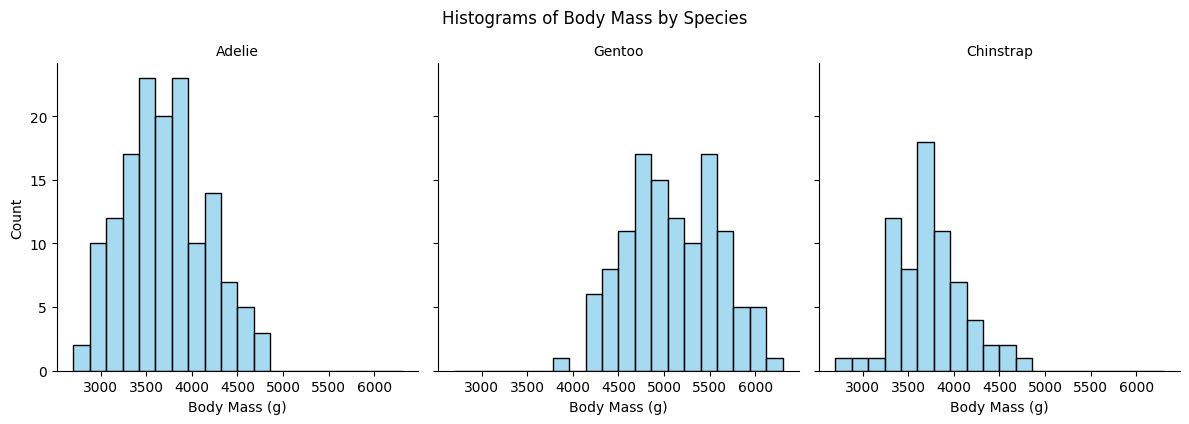

In [33]:
g = sns.displot(
    data=penguins_clean,
    x="body_mass_g",
    col="species",
    bins=20,
    col_wrap=3,
    height=4,
    aspect=1,
    color="skyblue"
)

g.set_axis_labels("Body Mass (g)", "Count")
g.set_titles("{col_name}")
g.fig.suptitle("Histograms of Body Mass by Species", y=1.05)

plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

/var/folders/tw/rwqn2kl51jq99k79tyr_45b00000gn/T/ipykernel_69639/1094730273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


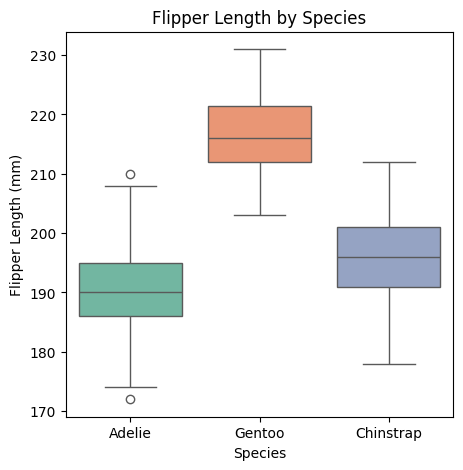

In [ ]:
plt.figure(figsize=(5, 5))

sns.boxplot(
    data=penguins_clean,
    x="species",
    y="flipper_length_mm",
    palette="Set2"
)

plt.title("Flipper Length by Species")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")

plt.show()

Gentoo penguins have the highest median flipper length； Adelie penguins have the lowest median with a few outliers on both ends；Chinstrap penguins are in the middle, and the spreads look fairly similar across species.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

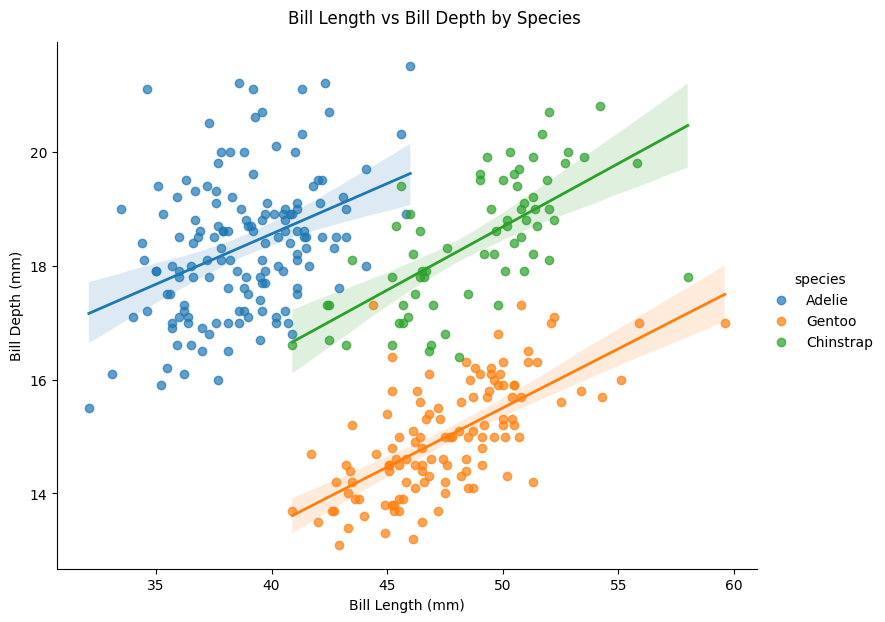

In [36]:
graph = sns.lmplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    height=6,
    aspect=1.3,
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2}
)

graph.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
graph.fig.suptitle("Bill Length vs Bill Depth by Species", y=1.03)

plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

sex        female  male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61


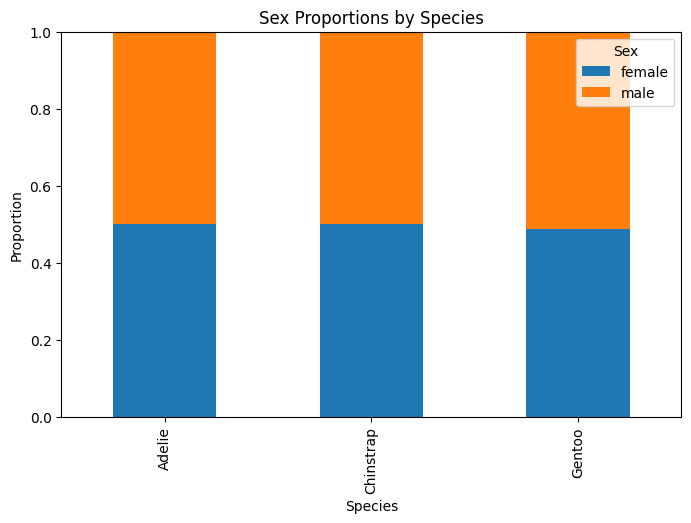

In [39]:
sex_counts = pd.crosstab(penguins_clean["species"],penguins_clean["sex"])
print(sex_counts)

sex_props = sex_counts.div(sex_counts.sum(axis=1), axis=0)

sex_props.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Sex Proportions by Species")
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.legend(title="Sex")
plt.ylim(0, 1)
plt.show()